# Exploratory Data Analysis for CSE 151B Math Competition Dataset

This notebook performs basic EDA on the public dataset to understand the structure and characteristics of the math problems.

In [3]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

In [1]:
# Install required packages if not already installed
import sys
!{sys.executable} -m pip install pandas matplotlib seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached numpy-2.4.4-cp311-cp311-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pillow-12.2.0-cp311-cp311-macosx_11_0_arm64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 15.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 12.6 MB/s  0:00:00 eta 0:00:01
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 12.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 13.3 MB/s  0:00:00 eta 0:00:01
Using cached pillow-12.2.0-cp311-cp311-macosx_11_0_arm64.whl (4.7 MB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10/10 [seaborn]8/10 [matp

In [4]:
# Load the dataset
data = []
with open('data/public.jsonl', 'r') as f:
    for line in f:
        data.append(json.loads(line))

# Convert to DataFrame
df = pd.DataFrame(data)
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Dataset shape: (1126, 4)
Columns: ['question', 'answer', 'id', 'options']


,question,answer,id,options
0,Find the sum of the first $325$ positive even ...,[325*(1+325)],0,NaN
1,$int_{-infty}^{+infty} frac{a^{3/2}}{s^2+a^2} ...,F,1,"[$0$, $frac{1}{a}$, $frac{3}{a}$, $frac{1}{2a^..."
2,A roasted turkey is taken from an oven when it...,"[143.224229233795, 2.32624773420025]",2,NaN
3,Reduce the fraction ${\frac{25}{40}}$. [ANS],[5/8],3,NaN
4,"Given $u(x, y) = x^3 + 6x^2y - 3xy^2 - 2y^3$, ...",C,4,"[$$\n( 6+4 \mathrm{i} ) z^{5}\n$$, $$\n( 4-5 \..."


In [5]:
# Basic statistics
print("Basic Statistics:")
print(f"Total samples: {len(df)}")
print(f"Questions with options: {df['options'].notna().sum()}")
print(f"Questions without options: {df['options'].isna().sum()}")

# Question length analysis
df['question_length'] = df['question'].apply(len)
print(f"Average question length: {df['question_length'].mean():.1f} characters")
print(f"Min question length: {df['question_length'].min()}")
print(f"Max question length: {df['question_length'].max()}")

# Answer analysis
def analyze_answer(ans):
    if isinstance(ans, list):
        return len(ans)
    elif isinstance(ans, str):
        return 1
    else:
        return 0

df['num_answers'] = df['answer'].apply(analyze_answer)
print(f"Average number of answers per question: {df['num_answers'].mean():.2f}")
print(f"Max answers in one question: {df['num_answers'].max()}")

Basic Statistics:
Total samples: 1126
Questions with options: 375
Questions without options: 751
Average question length: 373.9 characters
Min question length: 25
Max question length: 4283
Average number of answers per question: 2.02
Max answers in one question: 42


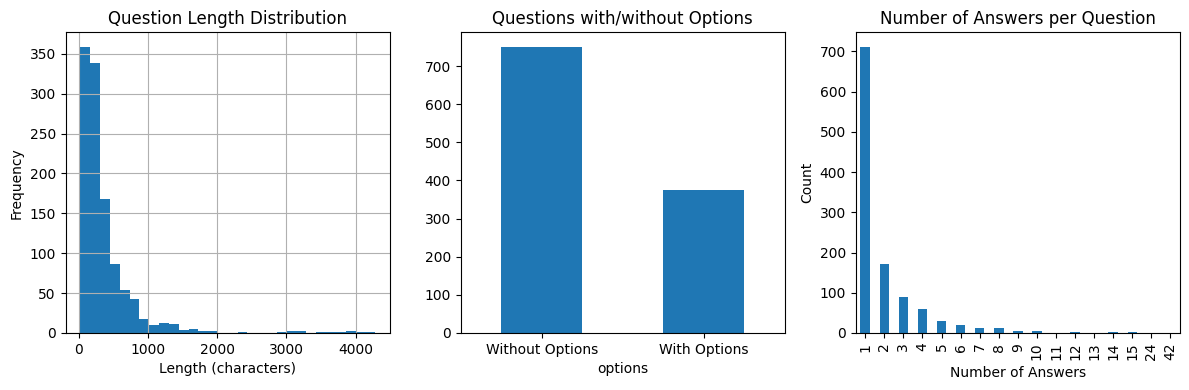

In [6]:
# Visualizations
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
df['question_length'].hist(bins=30)
plt.title('Question Length Distribution')
plt.xlabel('Length (characters)')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
has_options = df['options'].notna().value_counts()
has_options.plot(kind='bar')
plt.title('Questions with/without Options')
plt.xticks([0, 1], ['Without Options', 'With Options'], rotation=0)

plt.subplot(1, 3, 3)
df['num_answers'].value_counts().sort_index().plot(kind='bar')
plt.title('Number of Answers per Question')
plt.xlabel('Number of Answers')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

Question topics:
topic
other          577
algebra        275
geometry        80
probability     78
statistics      57
calculus        49
temperature      7
physics          3
Name: count, dtype: int64


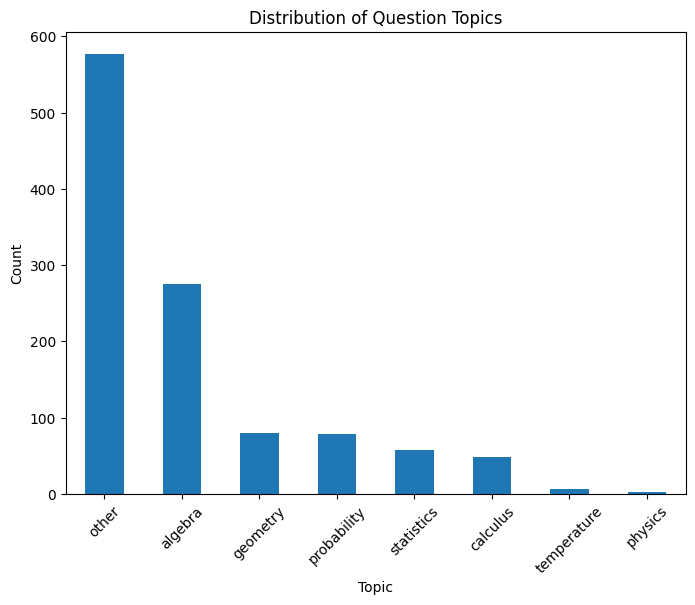

In [7]:
# Analyze question topics (basic keyword search)
math_topics = {
    'algebra': ['equation', 'solve', 'variable', 'function', 'polynomial'],
    'calculus': ['integral', 'derivative', 'limit', 'differential'],
    'geometry': ['triangle', 'circle', 'area', 'volume', 'angle'],
    'probability': ['probability', 'chance', 'random', 'expected'],
    'statistics': ['mean', 'median', 'variance', 'distribution'],
    'physics': ['force', 'velocity', 'acceleration', 'energy'],
    'temperature': ['fahrenheit', 'celsius', 'kelvin', 'rankine']
}

def categorize_question(q):
    q_lower = q.lower()
    for topic, keywords in math_topics.items():
        if any(kw in q_lower for kw in keywords):
            return topic
    return 'other'

df['topic'] = df['question'].apply(categorize_question)
topic_counts = df['topic'].value_counts()
print("Question topics:")
print(topic_counts)

# Plot topics
plt.figure(figsize=(8, 6))
topic_counts.plot(kind='bar')
plt.title('Distribution of Question Topics')
plt.xlabel('Topic')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [9]:
# Check for missing data
print("Missing Data Analysis:")
print(df.isnull().sum())
print("\nPercentage of missing data:")
print((df.isnull().sum() / len(df)) * 100)

# Check for empty strings or None in answers
def check_empty_answer(ans):
    if isinstance(ans, list):
        return any(not str(a).strip() for a in ans)
    elif isinstance(ans, str):
        return not ans.strip()
    else:
        return True

empty_answers = df['answer'].apply(check_empty_answer).sum()
print(f"\nQuestions with empty answers: {empty_answers}")

# Check questions
empty_questions = df['question'].apply(lambda x: not str(x).strip()).sum()
print(f"Questions with empty text: {empty_questions}")

Missing Data Analysis:
question             0
answer               0
id                   0
options            751
question_length      0
num_answers          0
topic                0
dtype: int64

Percentage of missing data:
question            0.00000
answer              0.00000
id                  0.00000
options            66.69627
question_length     0.00000
num_answers         0.00000
topic               0.00000
dtype: float64

Questions with empty answers: 0
Questions with empty text: 0


In [10]:
# Analyze LaTeX usage and format for Qwen3-4B
import re

def has_latex(text):
    # Check for LaTeX delimiters: $...$, $$...$$, \(...\), \[...\]
    latex_patterns = [
        r'\$.*?\$',  # inline math
        r'\$\$.*?\$\$',  # display math
        r'\\\(.*?\\\)',  # inline with parentheses
        r'\\\[.*?\\\]',  # display with brackets
        r'\\frac\{.*?\}\{.*?\}',  # fractions
        r'\\int',  # integrals
        r'\\sum',  # sums
        r'\\lim',  # limits
        r'\\sqrt',  # square roots
        r'\\mathrm\{.*?\}',  # roman text
        r'\\mathrm\{.*?\}',  # other math commands
    ]
    text_str = str(text)
    for pattern in latex_patterns:
        if re.search(pattern, text_str, re.DOTALL):
            return True
    return False

df['has_latex_question'] = df['question'].apply(has_latex)
df['has_latex_answer'] = df['answer'].apply(has_latex)

print("LaTeX Usage Analysis:")
print(f"Questions with LaTeX: {df['has_latex_question'].sum()} ({df['has_latex_question'].mean()*100:.1f}%)")
print(f"Answers with LaTeX: {df['has_latex_answer'].sum()} ({df['has_latex_answer'].mean()*100:.1f}%)")

# Check answer formats
def answer_format(ans):
    if isinstance(ans, list):
        if len(ans) == 1:
            return 'single_list'
        else:
            return 'multi_list'
    elif isinstance(ans, str) and len(ans) == 1 and ans.isalpha():
        return 'letter_option'
    elif isinstance(ans, str):
        return 'text_answer'
    else:
        return 'other'

df['answer_format'] = df['answer'].apply(answer_format)
print("\nAnswer Format Distribution:")
print(df['answer_format'].value_counts())

# Sample questions with/without LaTeX
print("\nSample question with LaTeX:")
latex_sample = df[df['has_latex_question']].sample(1)['question'].iloc[0]
print(latex_sample[:200] + "..." if len(latex_sample) > 200 else latex_sample)

print("\nSample question without LaTeX:")
no_latex_sample = df[~df['has_latex_question']].sample(1)['question'].iloc[0]
print(no_latex_sample[:200] + "..." if len(no_latex_sample) > 200 else no_latex_sample)

LaTeX Usage Analysis:
Questions with LaTeX: 896 (79.6%)
Answers with LaTeX: 0 (0.0%)

Answer Format Distribution:
answer_format
multi_list       414
letter_option    375
single_list      327
text_answer       10
Name: count, dtype: int64

Sample question with LaTeX:
Find a polar equation for the ellipse that has its focus at the pole and satisfies the stated conditions. Enter t for the variable $\theta$.
(a) Directrix to the right of the pole; $b=$ 5 and $e=\frac...

Sample question without LaTeX:
Since 1966, 45\% of the No.1 draftpicks in the NBA have been centers.
identify the population [ANS] A. all No.1 draftpick centers in the NBA since 1966  B. all NBA players since 1966  C. all No.1 draf...
